In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikitabisht/menstrual-cycle-data")

print("Path to dataset files:", path)

/Users/adwaitmahajan/miniconda3/envs/aster/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/adwaitmahajan/.cache/kagglehub/datasets/nikitabisht/menstrual-cycle-data/versions/1


In [2]:
import os

data_path = '/Users/adwaitmahajan/.cache/kagglehub/datasets/nikitabisht/menstrual-cycle-data/versions/1'
files = os.listdir(data_path)
print(files)

['FedCycleData071012 (2).csv']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [18]:
df = pd.read_csv(os.path.join(data_path, 'FedCycleData071012 (2).csv'), na_values=[" "])

In [22]:
df.head()

,ClientID,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,...,Method,Prevmethod,Methoddate,Whychart,Nextpreg,NextpregM,Spousesame,SpousesameM,Timeattemptpreg,BMI
0,nfp8122,1,0,1,0,29,27.33,17.0,12.0,12.0,...,9.0,NaN,NaN,2.0,7.0,7.0,1.0,1.0,0.0,21.254724
1,nfp8122,2,0,1,0,27,NaN,15.0,12.0,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,nfp8122,3,0,1,0,29,NaN,15.0,14.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,nfp8122,4,0,1,0,27,NaN,15.0,12.0,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,nfp8122,5,0,1,0,28,NaN,16.0,12.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

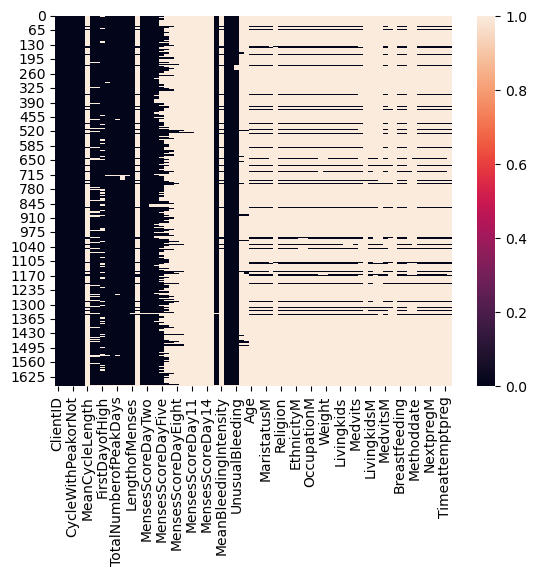

In [23]:
sns.heatmap(df.isna())

In [26]:
threshold = len(df) * 0.5
df.dropna(axis=1, thresh=threshold, inplace=True)

<Axes: >

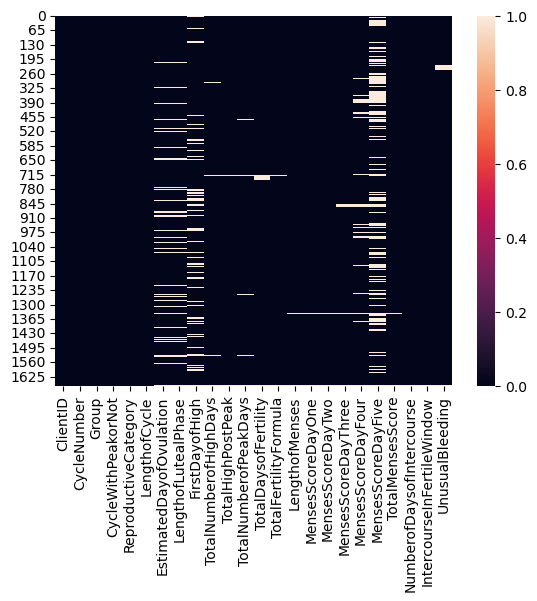

In [28]:
sns.heatmap(df.isna())

In [32]:
missing_percent = df.isna().mean() * 100
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

MensesScoreDayFive            26.066066
FirstDayofHigh                15.495495
LengthofLutealPhase            9.069069
EstimatedDayofOvulation        9.009009
MensesScoreDayFour             5.225225
TotalDaysofFertility           1.861862
MensesScoreDayThree            1.501502
UnusualBleeding                1.201201
TotalNumberofPeakDays          0.960961
TotalNumberofHighDays          0.720721
LengthofMenses                 0.240240
MensesScoreDayTwo              0.240240
TotalMensesScore               0.240240
MensesScoreDayOne              0.240240
TotalHighPostPeak              0.180180
TotalFertilityFormula          0.120120
NumberofDaysofIntercourse      0.060060
IntercourseInFertileWindow     0.060060
dtype: float64


In [38]:
df.drop(axis=1, columns=['ClientID'], inplace=True)

In [48]:
df.drop(axis=1, columns=['MensesScoreDayFive'], inplace=True)

In [51]:
df_cleaned = df.fillna(df.median(numeric_only=True))

In [58]:
df_cleaned.isnull().sum()

CycleNumber                   0
Group                         0
CycleWithPeakorNot            0
ReproductiveCategory          0
LengthofCycle                 0
EstimatedDayofOvulation       0
LengthofLutealPhase           0
FirstDayofHigh                0
TotalNumberofHighDays         0
TotalHighPostPeak             0
TotalNumberofPeakDays         0
TotalDaysofFertility          0
TotalFertilityFormula         0
LengthofMenses                0
MensesScoreDayOne             0
MensesScoreDayTwo             0
MensesScoreDayThree           0
MensesScoreDayFour            0
TotalMensesScore              0
NumberofDaysofIntercourse     0
IntercourseInFertileWindow    0
UnusualBleeding               0
dtype: int64

In [59]:
from pathlib import Path

output_dir = Path("data") / "Main Data"
output_dir.mkdir(parents=True, exist_ok=True)

In [60]:
output_path = output_dir / "cleaned_cycle_data.csv"
df_cleaned.to_csv(output_path, index=False)

print(f"Saved cleaned data to: {output_path}")

Saved cleaned data to: data/Main Data/cleaned_cycle_data.csv


In [61]:
df_cleaned

,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,TotalNumberofHighDays,TotalHighPostPeak,...,TotalFertilityFormula,LengthofMenses,MensesScoreDayOne,MensesScoreDayTwo,MensesScoreDayThree,MensesScoreDayFour,TotalMensesScore,NumberofDaysofIntercourse,IntercourseInFertileWindow,UnusualBleeding
0,1,0,1,0,29,17.0,12.0,12.0,5.0,0.0,...,15.0,5.0,3.0,3.0,2.0,1.0,10.0,5.0,1.0,0.0
1,2,0,1,0,27,15.0,12.0,13.0,2.0,0.0,...,13.0,5.0,3.0,3.0,2.0,1.0,10.0,6.0,1.0,0.0
2,3,0,1,0,29,15.0,14.0,11.0,1.0,0.0,...,13.0,5.0,3.0,3.0,2.0,1.0,10.0,5.0,1.0,0.0
3,4,0,1,0,27,15.0,12.0,13.0,2.0,0.0,...,13.0,5.0,3.0,3.0,3.0,2.0,12.0,3.0,0.0,0.0
4,5,0,1,0,28,16.0,12.0,12.0,4.0,0.0,...,14.0,5.0,3.0,3.0,2.0,2.0,11.0,5.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,7,1,1,0,29,19.0,10.0,13.0,5.0,0.0,...,15.0,8.0,2.0,3.0,3.0,2.0,15.0,8.0,0.0,1.0
1661,8,1,1,0,28,17.0,11.0,12.0,3.0,0.0,...,13.0,6.0,3.0,3.0,2.0,1.0,11.0,11.0,1.0,0.0
1662,9,1,1,0,28,16.0,12.0,11.0,4.0,0.0,...,12.0,5.0,3.0,2.0,2.0,1.0,9.0,7.0,0.0,0.0
1663,10,1,1,1,40,27.0,13.0,13.0,13.0,0.0,...,24.0,6.0,2.0,3.0,3.0,2.0,12.0,3.0,0.0,0.0


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [Text(0, 0, 'CycleNumber'),
  Text(1, 0, 'CycleWithPeakorNot'),
  Text(2, 0, 'MensesScoreDayTwo'),
  Text(3, 0, 'MensesScoreDayThree'),
  Text(4, 0, 'Group'),
  Text(5, 0, 'TotalHighPostPeak'),
  Text(6, 0, 'MensesScoreDayOne'),
  Text(7, 0, 'TotalNumberofPeakDays'),
  Text(8, 0, 'MensesScoreDayFour'),
  Text(9, 0, 'ReproductiveCategory'),
  Text(10, 0, 'IntercourseInFertileWindow'),
  Text(11, 0, 'TotalMensesScore'),
  Text(12, 0, 'NumberofDaysofIntercourse'),
  Text(13, 0, 'TotalNumberofHighDays'),
  Text(14, 0, 'LengthofMenses'),
  Text(15, 0, 'UnusualBleeding'),
  Text(16, 0, 'TotalDaysofFertility'),
  Text(17, 0, 'LengthofLutealPhase'),
  Text(18, 0, 'FirstDayofHigh'),
  Text(19, 0, 'TotalFertilityFormula'),
  Text(20, 0, 'EstimatedDayofOvulation')])

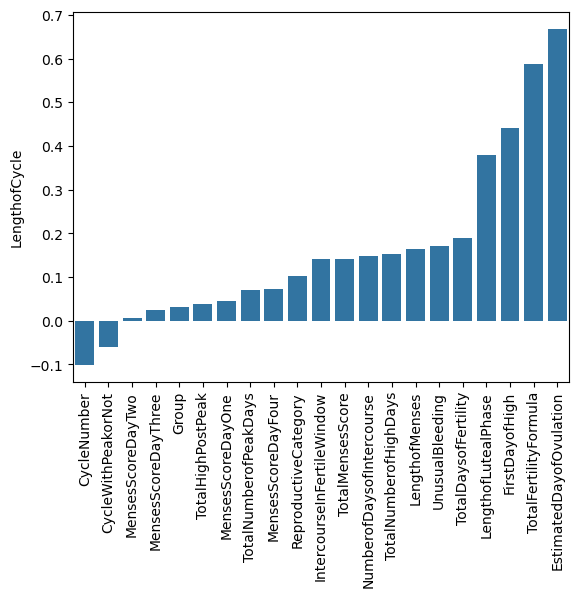

In [63]:
sns.barplot(df_cleaned.corr()['LengthofCycle'].sort_values(ascending=True)[:-1])
plt.xticks(rotation=90)

In [69]:
df_cleaned.iloc[1]

CycleNumber                    2.0
Group                          0.0
CycleWithPeakorNot             1.0
ReproductiveCategory           0.0
LengthofCycle                 27.0
EstimatedDayofOvulation       15.0
LengthofLutealPhase           12.0
FirstDayofHigh                13.0
TotalNumberofHighDays          2.0
TotalHighPostPeak              0.0
TotalNumberofPeakDays          2.0
TotalDaysofFertility           6.0
TotalFertilityFormula         13.0
LengthofMenses                 5.0
MensesScoreDayOne              3.0
MensesScoreDayTwo              3.0
MensesScoreDayThree            2.0
MensesScoreDayFour             1.0
TotalMensesScore              10.0
NumberofDaysofIntercourse      6.0
IntercourseInFertileWindow     1.0
UnusualBleeding                0.0
Name: 1, dtype: float64

In [4]:
df_cleaned = pd.read_csv('/Users/adwaitmahajan/Desktop/Aster Health/aster-health-app/data/Main Data/cleaned_cycle_data.csv')

In [7]:
df_cleaned.drop(columns=['Group','CycleNumber'], axis=1,inplace=True)

In [8]:
df_cleaned

,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,TotalNumberofHighDays,TotalHighPostPeak,TotalNumberofPeakDays,TotalDaysofFertility,TotalFertilityFormula,LengthofMenses,MensesScoreDayOne,MensesScoreDayTwo,MensesScoreDayThree,MensesScoreDayFour,TotalMensesScore,NumberofDaysofIntercourse,IntercourseInFertileWindow,UnusualBleeding
0,1,0,29,17.0,12.0,12.0,5.0,0.0,2.0,9.0,15.0,5.0,3.0,3.0,2.0,1.0,10.0,5.0,1.0,0.0
1,1,0,27,15.0,12.0,13.0,2.0,0.0,2.0,6.0,13.0,5.0,3.0,3.0,2.0,1.0,10.0,6.0,1.0,0.0
2,1,0,29,15.0,14.0,11.0,1.0,0.0,2.0,5.0,13.0,5.0,3.0,3.0,2.0,1.0,10.0,5.0,1.0,0.0
3,1,0,27,15.0,12.0,13.0,2.0,0.0,2.0,6.0,13.0,5.0,3.0,3.0,3.0,2.0,12.0,3.0,0.0,0.0
4,1,0,28,16.0,12.0,12.0,4.0,0.0,2.0,8.0,14.0,5.0,3.0,3.0,2.0,2.0,11.0,5.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,1,0,29,19.0,10.0,13.0,5.0,0.0,3.0,10.0,15.0,8.0,2.0,3.0,3.0,2.0,15.0,8.0,0.0,1.0
1661,1,0,28,17.0,11.0,12.0,3.0,0.0,4.0,9.0,13.0,6.0,3.0,3.0,2.0,1.0,11.0,11.0,1.0,0.0
1662,1,0,28,16.0,12.0,11.0,4.0,0.0,3.0,9.0,12.0,5.0,3.0,2.0,2.0,1.0,9.0,7.0,0.0,0.0
1663,1,1,40,27.0,13.0,13.0,13.0,0.0,1.0,7.0,24.0,6.0,2.0,3.0,3.0,2.0,12.0,3.0,0.0,0.0


In [10]:
df_cleaned.dtypes

CycleWithPeakorNot              int64
ReproductiveCategory            int64
LengthofCycle                   int64
EstimatedDayofOvulation       float64
LengthofLutealPhase           float64
FirstDayofHigh                float64
TotalNumberofHighDays         float64
TotalHighPostPeak             float64
TotalNumberofPeakDays         float64
TotalDaysofFertility          float64
TotalFertilityFormula         float64
LengthofMenses                float64
MensesScoreDayOne             float64
MensesScoreDayTwo             float64
MensesScoreDayThree           float64
MensesScoreDayFour            float64
TotalMensesScore              float64
NumberofDaysofIntercourse     float64
IntercourseInFertileWindow    float64
UnusualBleeding               float64
dtype: object

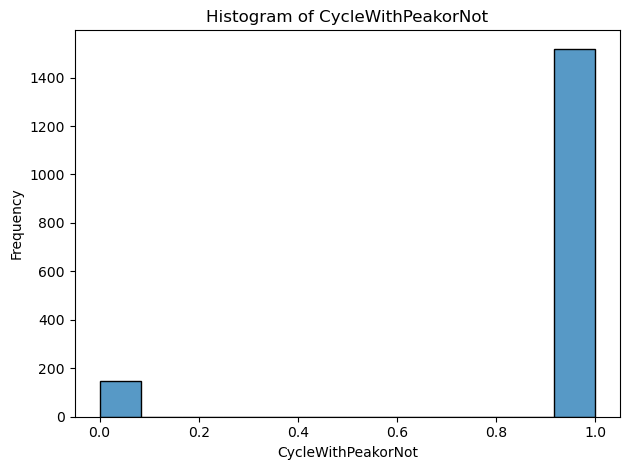

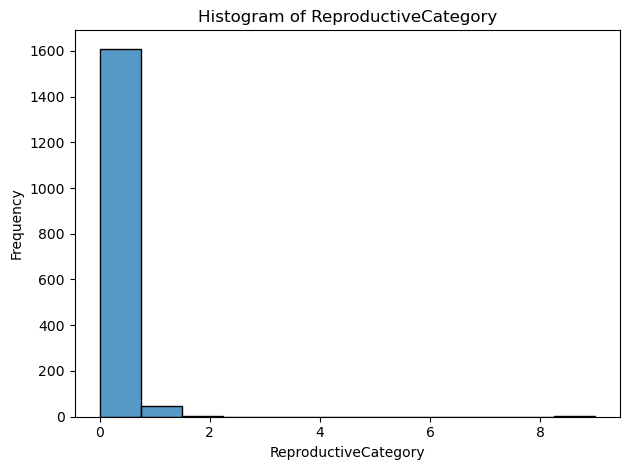

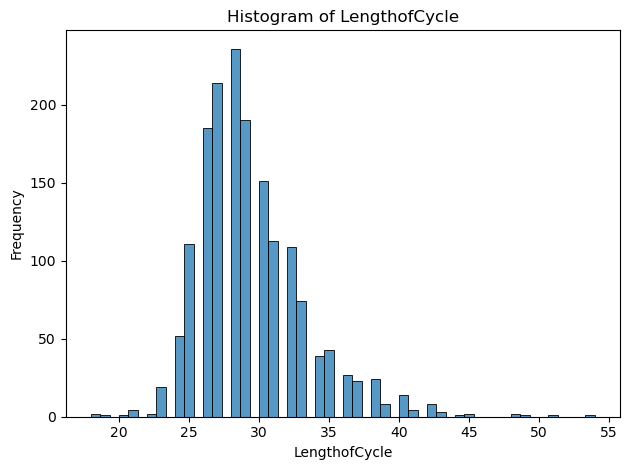

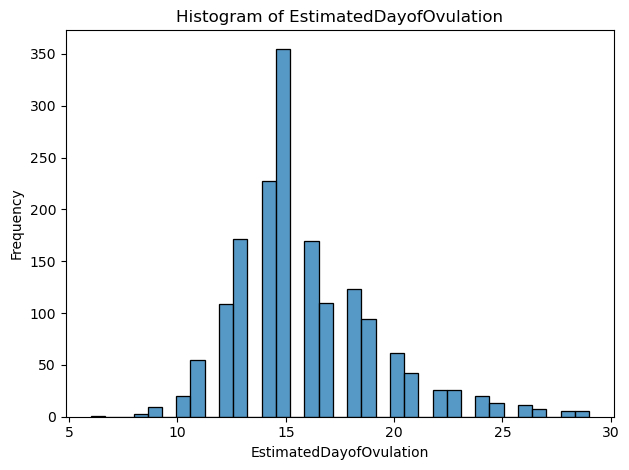

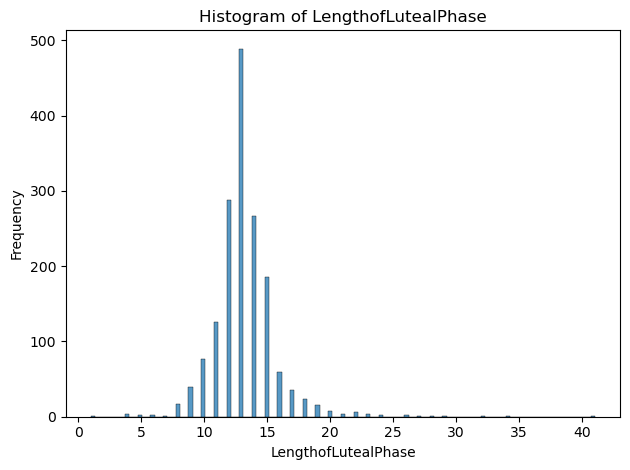

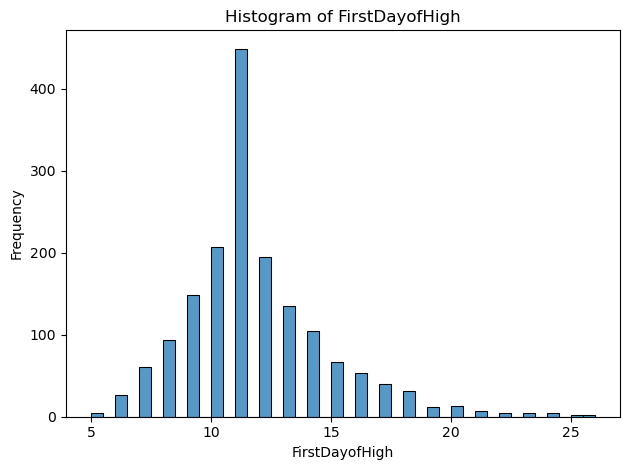

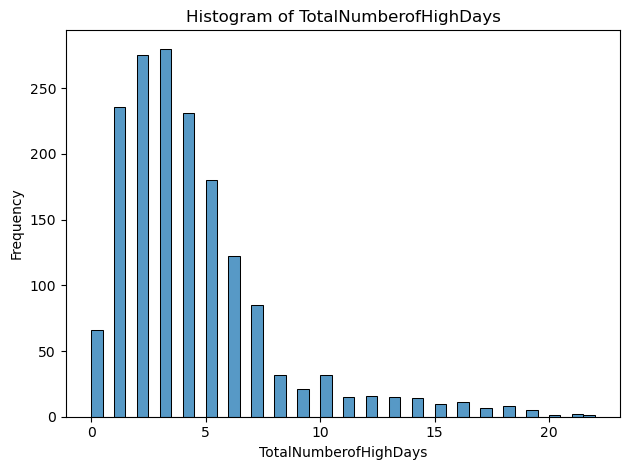

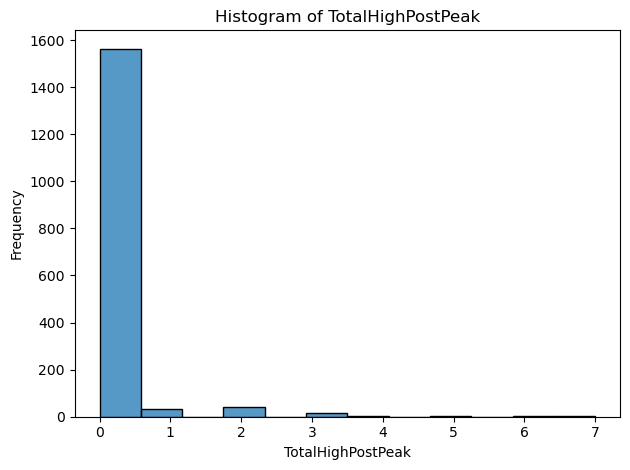

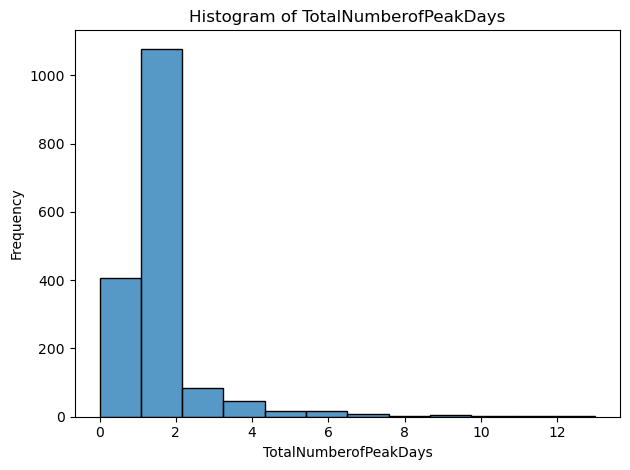

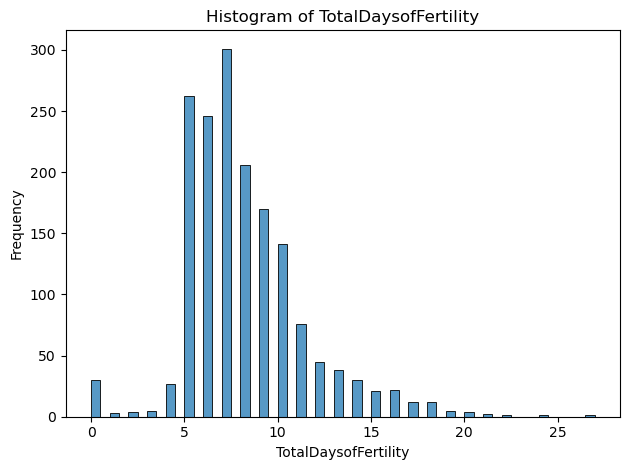

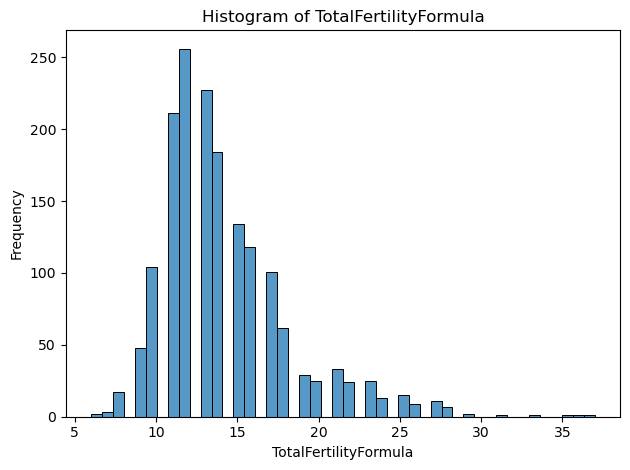

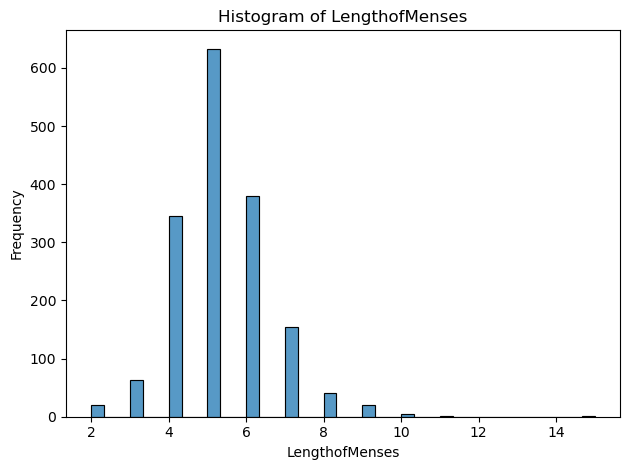

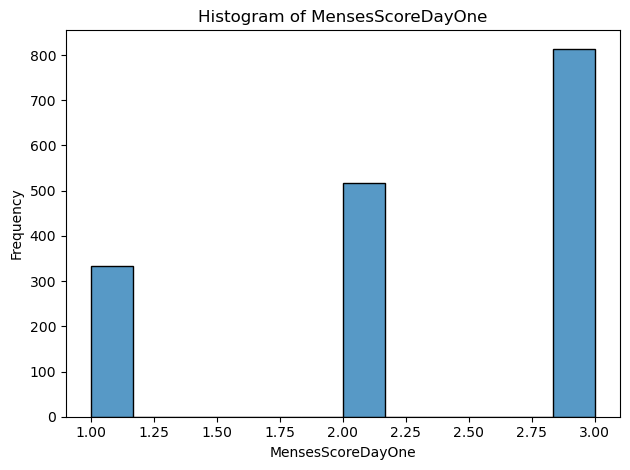

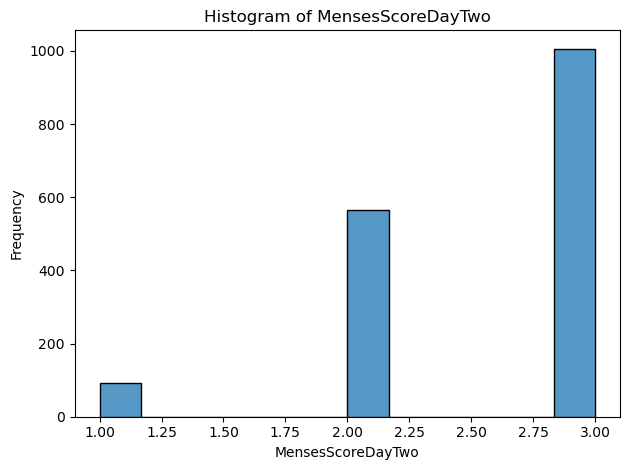

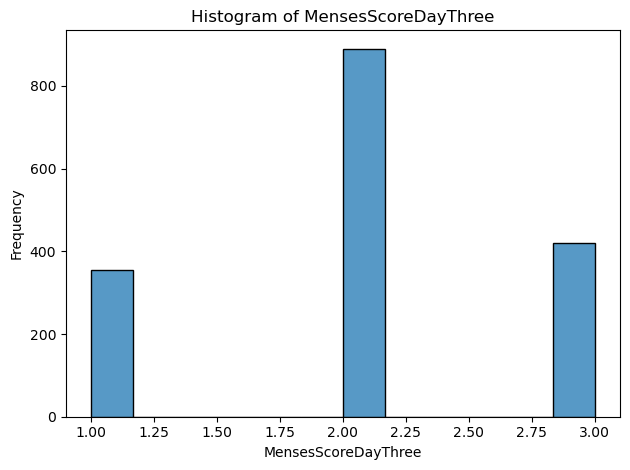

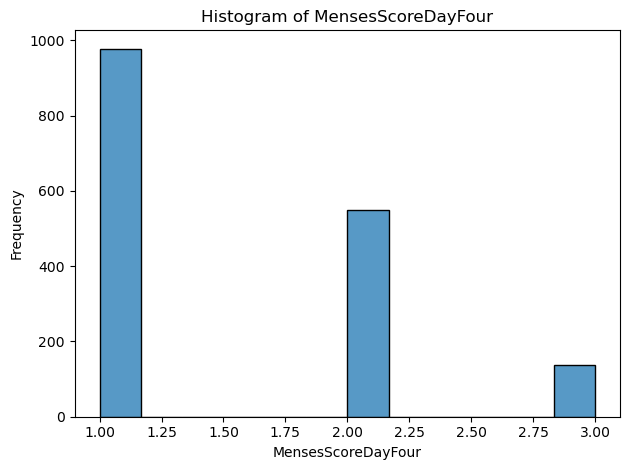

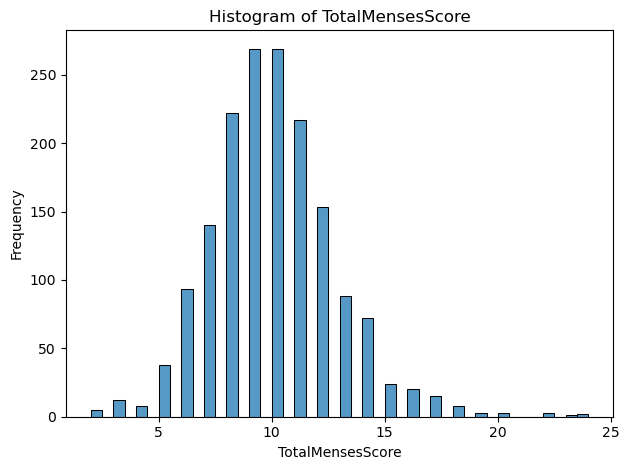

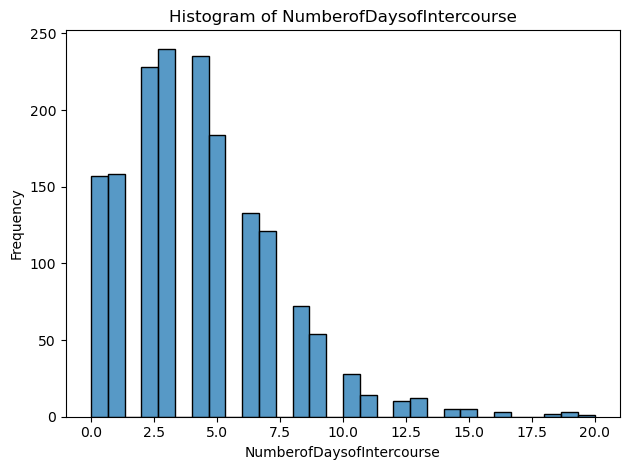

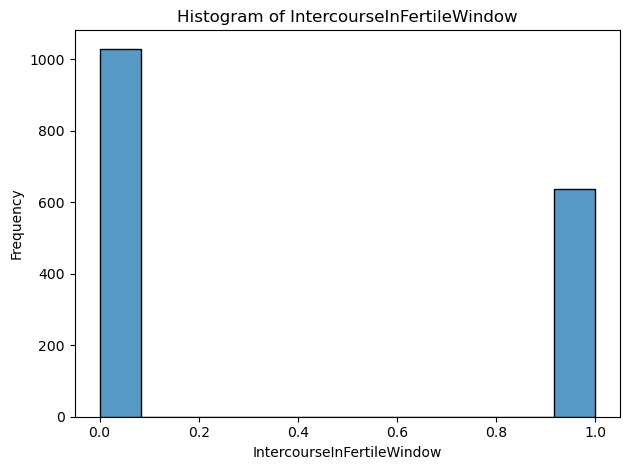

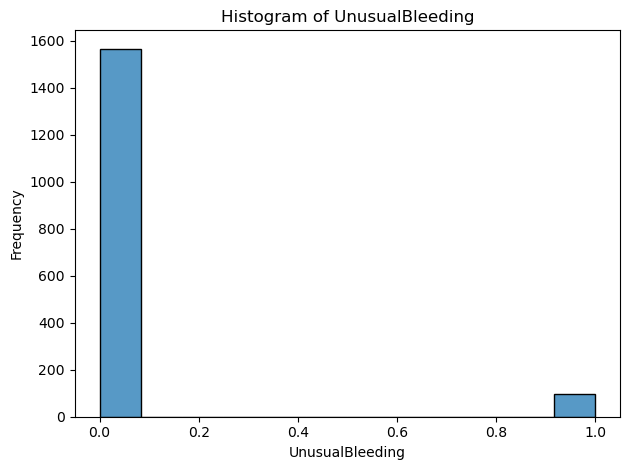

In [14]:
for i in df_cleaned.columns:
    sns.histplot(data=df_cleaned, x=i)
    plt.title(f"Histogram of {i}")
    plt.xlabel(i)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [16]:
df_cleaned.iloc[1]

CycleWithPeakorNot             1.0
ReproductiveCategory           0.0
LengthofCycle                 27.0
EstimatedDayofOvulation       15.0
LengthofLutealPhase           12.0
FirstDayofHigh                13.0
TotalNumberofHighDays          2.0
TotalHighPostPeak              0.0
TotalNumberofPeakDays          2.0
TotalDaysofFertility           6.0
TotalFertilityFormula         13.0
LengthofMenses                 5.0
MensesScoreDayOne              3.0
MensesScoreDayTwo              3.0
MensesScoreDayThree            2.0
MensesScoreDayFour             1.0
TotalMensesScore              10.0
NumberofDaysofIntercourse      6.0
IntercourseInFertileWindow     1.0
UnusualBleeding                0.0
Name: 1, dtype: float64

FINAL FEATURE DECISION

🟢 User Inputs (Required/Recommended):

Feature Name	                    Description

LengthofCycle	                    -> Ask for average cycle length or calculate using Start Date & End Date

LengthofMenses	                    -> Ask for number of days with bleeding

MensesScoreDayOne	                -> Ask for bleeding intensity on Day 1 (scale 1–4)

MensesScoreDayTwo	                -> Bleeding intensity on Day 2

MensesScoreDayThree	                -> Bleeding intensity on Day 3

MensesScoreDayFour	                -> Bleeding intensity on Day 4

EstimatedDayofOvulation	            -> Ask if user uses ovulation tests, else infer (default Day 14 in 28-day cycle)

UnusualBleeding	                    -> Yes/No toggle

IntercourseInFertileWindow	        -> Yes/No toggle (if user tracks intercourse dates and cycle phases)

🔵 Derived Features (Auto-calculated):

Feature Name	                    Logic

TotalMensesScore                    -> MensesScoreDayOne + MensesScoreDayTwo + MensesScoreDayThree + MensesScoreDayFour

LengthofLutealPhase	                -> LengthofCycle - EstimatedDayofOvulation (or assume default 12–14 days)

Ovulation Day	                    -> LengthofCycle - LengthofLutealPhase

FirstDayofHigh	                    -> Ovulation Day - 5

TotalNumberofHighDays	            -> Default = 5 (or estimate from user tracking)

TotalNumberofPeakDays	            -> Default = 1–2

TotalDaysofFertility	            -> TotalNumberofHighDays + TotalNumberofPeakDays

CycleWithPeakorNot	                -> If EstimatedDayofOvulation is known or assumed + cycle length is regular → set to 1.0


🔴 User Inputs (Optional Enhancements):

Feature Name	                    Description

ReproductiveCategory	            -> Not covered	Drop for now – unclear coding (e.g., 0.0, 1.0...); needs documentation

TotalHighPostPeak	                -> Not covered	Drop – requires detailed daily mucus tracking (not feasible from current inputs)

TotalFertilityFormula	            -> Not covered	Drop – formula unknown, opaque, not needed if we compute actual fertility range

NumberofDaysofIntercourse           -> Optional input or derived from Intercourse Dates	Add as optional enhancement if tracking intercourse dates

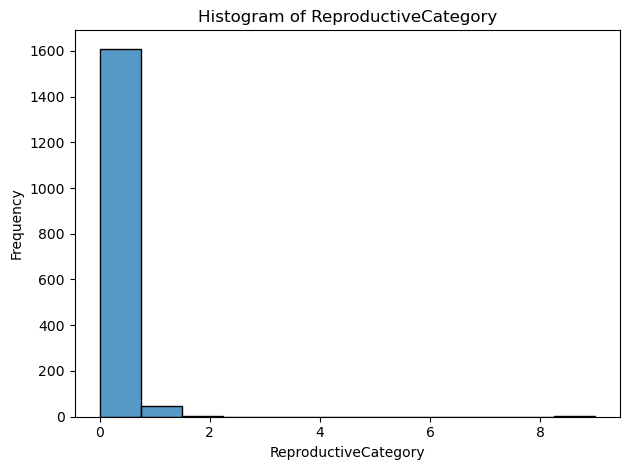

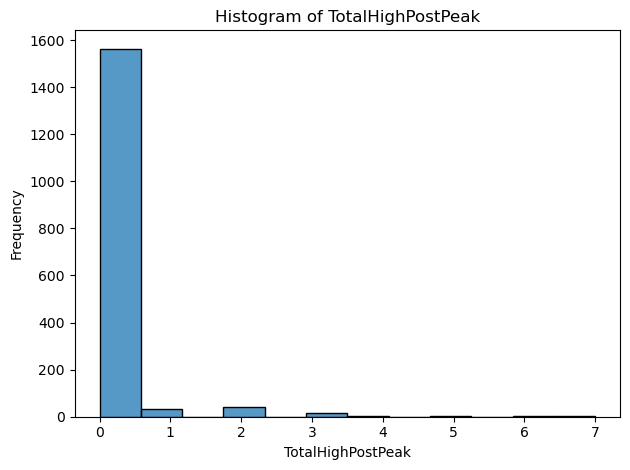

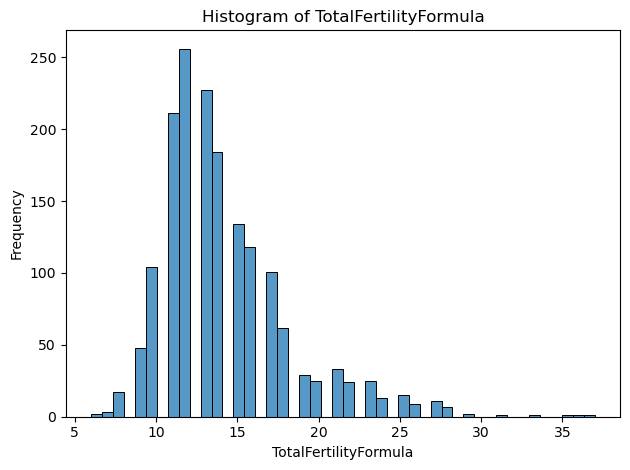

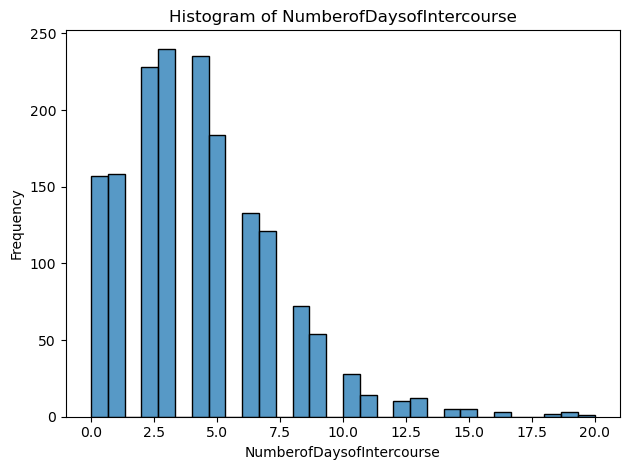

In [24]:
drop_columns = ['ReproductiveCategory','TotalHighPostPeak','TotalFertilityFormula','NumberofDaysofIntercourse']
for i in drop_columns:
    sns.histplot(data=df_cleaned, x=i)
    plt.title(f"Histogram of {i}")
    plt.xlabel(i)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [35]:
df_cleaned.drop(columns=drop_columns, axis=1, inplace=True)

THE DATASET HAS BEEN CLEANED

In [40]:
df_cleaned.columns

Index(['CycleWithPeakorNot', 'LengthofCycle', 'EstimatedDayofOvulation',
       'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays',
       'TotalNumberofPeakDays', 'TotalDaysofFertility', 'LengthofMenses',
       'MensesScoreDayOne', 'MensesScoreDayTwo', 'MensesScoreDayThree',
       'MensesScoreDayFour', 'TotalMensesScore', 'IntercourseInFertileWindow',
       'UnusualBleeding'],
      dtype='object')

In [41]:
from pathlib import Path

output_dir = Path("data") / "Main Data"
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "clean_data_for_ML.csv"
df_cleaned.to_csv(output_path, index=False)

print(f"Saved cleaned data to: {output_path}")

Saved cleaned data to: data/Main Data/clean_data_for_ML.csv


Model Building - basic

In [49]:
df_shuffled = df_cleaned.sample(frac=1, random_state=42).reset_index(drop=True)

In [50]:
from sklearn.preprocessing import MinMaxScaler

In [51]:
X = df_cleaned.drop(columns=['LengthofCycle'], axis=1)
y = df_cleaned['LengthofCycle']

In [52]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [56]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

In [54]:
X = pd.DataFrame(X_scaled, columns=X.columns)

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
rf_params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

In [58]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Performance:")
    print(f"Best Params: {name}_grid.best_params_")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"R²:   {r2_score(y_true, y_pred):.2f}")

In [59]:
evaluate_model("Random Forest", y_test, rf_best.predict(X_test))


Random Forest Performance:
Best Params: Random Forest_grid.best_params_
MAE:  0.50
RMSE: 1.40
R²:   0.86


Metric	Value	Interpretation

MAE	    0.50	On average, the model's predictions are off by half a day

RMSE	1.40	Errors are mostly within ±1.4 days

R²	    0.86	The model explains 86% of the variance in cycle length

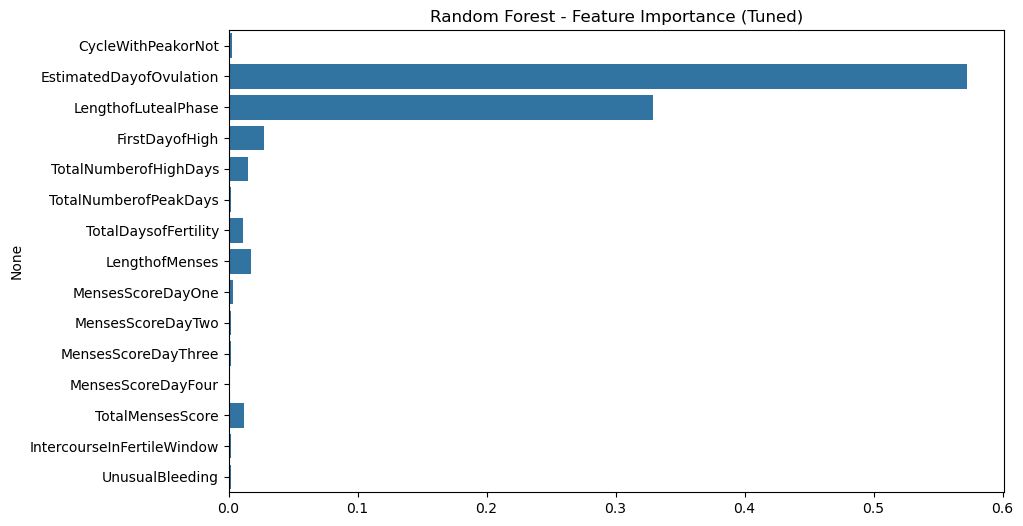

In [60]:
plt.figure(figsize=(10, 6))
sns.barplot(x=rf_best.feature_importances_, y=X.columns)
plt.title("Random Forest - Feature Importance (Tuned)")
plt.show()

In [61]:
import pickle
import os

# 1. Create the 'models' directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# 2. Define the file path
model_path = "models/random_forest_cycle_predictor.pkl"

# 3. Save the model using pickle
with open(model_path, "wb") as f:
    pickle.dump(rf_best, f)

print(f"✅ Random Forest model saved at: {model_path}")

✅ Random Forest model saved at: models/random_forest_cycle_predictor.pkl
